# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
print(f"Số dòng và số cột: {df.shape}")
print(f"Danh sách tên cột: {df.columns.tolist()}")
print(f"Kiểu dữ liệu:\n{df.dtypes}")

Số dòng và số cột: (541909, 8)
Danh sách tên cột: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Kiểu dữ liệu:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


## A.2. Missing values & Duplicate data

In [3]:
print("Số giá trị thiếu ở mỗi cột:")
print(df.isnull().sum())

print(f"Số dòng trùng lặp (Duplicate): {df.duplicated().sum()}")

Số giá trị thiếu ở mỗi cột:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Số dòng trùng lặp (Duplicate): 5268


## A.3. Invalid values

In [4]:
print(f"Số dòng có Quantity <= 0: {(df['Quantity'] <= 0).sum()}")
print(f"Số dòng có UnitPrice <= 0: {(df['UnitPrice'] <= 0).sum()}")

Số dòng có Quantity <= 0: 10624
Số dòng có UnitPrice <= 0: 2517


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [5]:
df.drop(df[df['Quantity'] <= 0].index, inplace=True)
df.drop(df[df['UnitPrice'] <= 0].index, inplace=True)

df['Sales'] = df['Quantity'] * df['UnitPrice']

display(df[['Quantity', 'UnitPrice', 'Sales']].head())

,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [7]:
cols_num = ['Quantity', 'UnitPrice', 'Sales']
for col in cols_num:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]
    print(f"{col}: Mean = {mean_val:.2f}, Median = {median_val:.2f}, Mode = {mode_val:.2f}")

cols_char = ['Country', 'Description']
for col in cols_char:
    mode_ = df[col].mode()[0]
    print(f"{col}: {mode_}")

Quantity: Mean = 10.54, Median = 3.00, Mode = 1.00
UnitPrice: Mean = 3.91, Median = 2.08, Mode = 1.25
Sales: Mean = 20.12, Median = 9.90, Mode = 15.00
Country: United Kingdom
Description: WHITE HANGING HEART T-LIGHT HOLDER


## Group 2 — Dispersion

In [8]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    s = df[col]
    range_ = s.max() - s.min()
    std_ = s.std()
    var_ = s.var()
    
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr_ = q3 - q1
    

    cv_ = std_ / s.mean()
    
    print(f"--- {col} ---")
    print(f"Range = {range_:.2f}, Std = {std_:.2f},Var = {var_:.2f} IQR = {iqr_:.2f}, CV = {cv_:.2f}")

--- Quantity ---
Range = 80994.00, Std = 155.52,Var = 24187.75 IQR = 9.00, CV = 14.75
--- UnitPrice ---
Range = 13541.33, Std = 35.92,Var = 1289.94 IQR = 2.88, CV = 9.19
--- Sales ---
Range = 168469.60, Std = 270.36,Var = 73092.77 IQR = 13.95, CV = 13.44


## Group 3 — Location and Shape

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


--- Quantity ---
P25 = 1.00, P50 = 3.00, P75 = 10.00
Skewness = 471.73, Kurtosis = 236460.11

--- UnitPrice ---
P25 = 1.25, P50 = 2.08, P75 = 4.13
Skewness = 206.09, Kurtosis = 62482.55

--- Sales ---
P25 = 3.75, P50 = 9.90, P75 = 17.70
Skewness = 506.70, Kurtosis = 297648.85



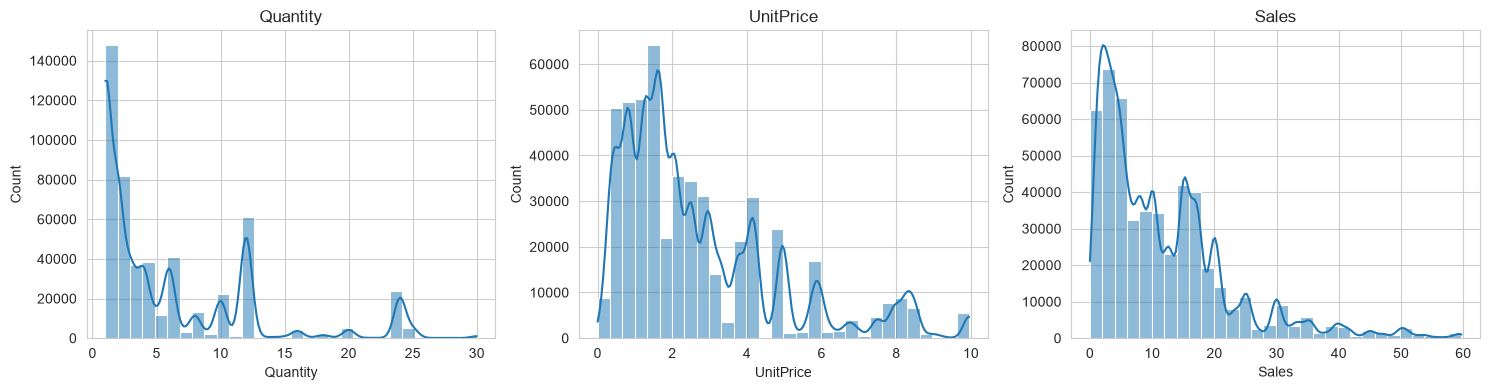

In [10]:

for col in ['Quantity', 'UnitPrice', 'Sales']:
    s = df[col]
    skew_val = stats.skew(s)
    kurt_val = stats.kurtosis(s)
    
    print(f"--- {col} ---")
    print(f"P25 = {s.quantile(0.25):.2f}, P50 = {s.quantile(0.5):.2f}, P75 = {s.quantile(0.75):.2f}")
    print(f"Skewness = {skew_val:.2f}, Kurtosis = {kurt_val:.2f}\n")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df[df['Quantity'] <= df['Quantity'].quantile(0.95)]['Quantity'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Quantity')

sns.histplot(df[df['UnitPrice'] <= df['UnitPrice'].quantile(0.95)]['UnitPrice'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('UnitPrice')

sns.histplot(df[df['Sales'] <= df['Sales'].quantile(0.95)]['Sales'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Sales')

plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [11]:
country_revenue = df.groupby('Country')['Sales'].sum()
country_pct = (country_revenue/df['Sales'].sum()) * 100

print(f'Dat nuoc co daonh thu cao nhat')

kq = pd.DataFrame({'Doanh thu': country_revenue, 'Ty le:': country_pct}).sort_values(by='Doanh thu', ascending=False)
display(kq.head(1).round(2))

Dat nuoc co daonh thu cao nhat


,Doanh thu,Ty le:
Country,,
United Kingdom,9025222.08,84.61


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [12]:
top_products = df.groupby(['StockCode', 'Description'])['Sales'].sum().sort_values(ascending=False)
print(top_products.head(1).round(2))


StockCode  Description   
DOT        DOTCOM POSTAGE    206248.77
Name: Sales, dtype: float64


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

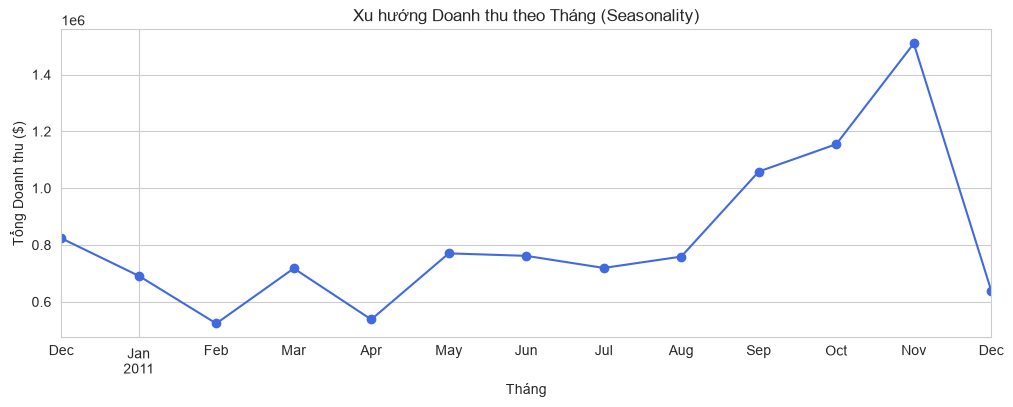

In [13]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

plt.figure(figsize=(12, 4))
monthly_sales.plot(kind='line', marker='o', color='royalblue')
plt.title('Xu hướng Doanh thu theo Tháng (Seasonality)')
plt.xlabel('Tháng')
plt.ylabel('Tổng Doanh thu ($)')
plt.grid(True)
plt.show()

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [14]:
country_summary = df.groupby('Country').agg(
    tong_doanh_thu=('Sales', 'sum'),
    so_don_hang=('InvoiceNo', 'nunique')
)

country_summary['AOV'] = country_summary['tong_doanh_thu'] / country_summary['so_don_hang']

aov_ranking = country_summary.sort_values(by='AOV', ascending=False)
display(aov_ranking.round(2).head(10))


,tong_doanh_thu,so_don_hang,AOV
Country,,,
Singapore,21279.29,7,3039.90
Netherlands,285446.34,94,3036.66
Australia,138521.31,57,2430.20
Japan,37416.37,19,1969.28
Lebanon,1693.88,1,1693.88
Hong Kong,15691.80,11,1426.53
Brazil,1143.60,1,1143.60
Sweden,38378.33,36,1066.06
Switzerland,57089.90,54,1057.22


## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [17]:
df['Is_Cancel'] = df['Quantity'] < 0

cancel_rate = (df.groupby('Country')['Is_Cancel'].mean()* 100).sort_values(ascending=False)

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,YearMonth,Is_Cancel
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,False


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

1. Hầu hết doanh thu đều tập trung vào Vương Quốc Anh (Chiếm 80%)
2. Doanh số có tính chất mùa vuj,doanh thu tăng trưởng vượt bậc vào quý 4 của năm do nhu cầu tăng mạnh
3. Tỷ lệ trả hàng/hủy đơn duy trì ở mức trung bình  tuy nhiên đối với các đơn hàng giá trị cao

